# Softmax分类器底层实现与超参调优
## 实验内容
1. 从零实现Softmax交叉熵损失函数，包含朴素循环版与纯向量化优化版；
2. 手动推导并实现解析梯度，通过数值梯度校验实现正确性；
3. 基于小批量SGD完成模型训练，在验证集上完成学习率、正则化强度超参寻优；
4. 可视化训练得到的分类权重，直观理解模型特征学习效果。

In [10]:
import random
from __future__ import print_function
import numpy as np
from datasets.data_utils import load_CIFAR10
import matplotlib.pyplot as plt
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']

# 让matplotlib图显示在 notebook，不要另外打开一个窗口
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 默认的绘图大小
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 自动加载外部类
# 详见 http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# 参数：训练集49000，验证集1000，测试集1000，开发集500
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    # 1. 加载原始 CIFAR-10 数据集
    cifar10_dir = '../datasets/cifar-10-batches-py'
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # 2. 拆分数据集：把原始数据切成 训练集/验证集/测试集/开发集
    # 验证集：从训练集的第49000个样本开始，取1000个（49000-49999）（用于训练时调参）
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]  # 验证集图片
    y_val = y_train[mask]  # 验证集标签
    # 训练集：取前49000个样本
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    # 测试集：取前1000个样本（减少数据量，加快测试）
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    # 开发集：从训练集随机抽500个（用于快速调试代码、检查梯度）
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]
    
    # 3. 数据预处理第一步：扁平化（展平）
    # CIFAR 原始图片是 32x32x3 的三维图像，reshape 变成 一维向量 (3072,)
    X_train = np.reshape(X_train, (X_train.shape[0], -1))   # -1表示自动计算维度，最终形状：(样本数, 32*32*3=3072)
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))
    
    # 4. 数据预处理第二步：归一化（减去均值）
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image
    
    # 5. 数据预处理第三步：添加偏置项
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev
'''
训练集：训练模型参数
验证集：调整超参数（学习率、正则化）
测试集：最终评估模型性能
开发集：快速调试代码（不用跑全量数据）
'''

# 清理旧数据，避免重复加载占用内存
try:
   del X_train, y_train
   del X_test, y_test
   print('先前加载的数据已经清除')
except:
   pass

# 调用上述方法加载数据
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('训练数据 shape: ', X_train.shape)
print('训练标签 shape: ', y_train.shape)
print('验证数据 shape: ', X_val.shape)
print('验证标签 shape: ', y_val.shape)
print('测试数据 shape: ', X_test.shape)
print('测试标签 shape: ', y_test.shape)
print('开发数据 shape: ', X_dev.shape)
print('开发标签 shape: ', y_dev.shape)

先前加载的数据已经清除
训练数据 shape:  (49000, 3073)
训练标签 shape:  (49000,)
验证数据 shape:  (1000, 3073)
验证标签 shape:  (1000,)
测试数据 shape:  (1000, 3073)
测试标签 shape:  (1000,)
开发数据 shape:  (500, 3073)
开发标签 shape:  (500,)


## Softmax 分类器

核心损失与梯度算法实现在 `classifiers/softmax.py` 中，分别提供朴素循环与纯向量化两个实现版本。


In [12]:
# 首先用内嵌的循环实现原始的softmax 损失函数计算损失，见方法 softmax_loss_naive

from classifiers.softmax import softmax_loss_naive
import time

# 随机生成 softmax 权重矩阵
W = np.random.randn(3073, 10) * 0.0001  # 乘 0.0001 是为了让权重很小且接近 0，避免初始分数过大
# 用他来计算损失及梯度
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)  #（暂时不加正则）

# 作为一个粗略的合理检查，损失应该是接近-log(0.1)
print('损失: %f' % loss)
print('合理值: %f' % (-np.log(0.1)))

损失: 2.365200
合理值: 2.302585


### 初始损失合理性验证
随机初始化权重下损失值应接近 -log(0.1)，可作为代码正确性的快速校验，逻辑如下：
1. 初始权重为极小随机值，各类别输出分数趋近于0；
2. 经过Softmax归一化后，10个类别的概率近似均匀分布，真实类别概率约为0.1；
3. 交叉熵损失为 -log(真实类别概率)，因此初始损失理论值约为 2.302585，与实验结果吻合，验证了损失函数实现的正确性。

In [13]:
# 完成方法 softmax_loss_naive 用原始的循环方法计算梯度
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# 用数值梯度检查解析梯度，这两个方法计算的梯度应该接近才对
from datasets.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]  # 定义一个只返回损失的lambda函数. lambda w: ...[0] ：给一个权重w，只返回对应的损失值（第0个返回值）
grad_numerical = grad_check_sparse(f, W, grad, 10)  # grad_check_sparse 会随机选 10 个权重维度，用有限差分法计算数值梯度，再和你的解析梯度 grad 对比
                                                    # 输出每一个维度的：数值梯度、解析梯度、两者的差异
print()
# 用正则化再检查一次梯度
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1) # 把正则化强度设为 5e1（比较强的正则），再跑一遍梯度检查. 目的是验证：你的梯度代码在加入正则项后依然正确
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

数值梯度: -0.429038 解析梯度: -0.429038, 差异: 1.112093e-08
数值梯度: -0.079932 解析梯度: -0.079931, 差异: 3.777137e-08
数值梯度: -2.816601 解析梯度: -2.816601, 差异: 5.203209e-10
数值梯度: -2.053206 解析梯度: -2.053206, 差异: 6.019883e-09
数值梯度: -1.948473 解析梯度: -1.948473, 差异: 4.864740e-09
数值梯度: -0.161796 解析梯度: -0.161796, 差异: 1.820856e-07
数值梯度: -2.423913 解析梯度: -2.423913, 差异: 2.431377e-08
数值梯度: -0.960341 解析梯度: -0.960341, 差异: 1.231849e-08
数值梯度: -0.819752 解析梯度: -0.819751, 差异: 6.732372e-08
数值梯度: -0.972955 解析梯度: -0.972955, 差异: 1.020863e-07

数值梯度: 3.178243 解析梯度: 3.178243, 差异: 2.208783e-08
数值梯度: 0.884354 解析梯度: 0.884353, 差异: 3.463529e-08
数值梯度: -2.557198 解析梯度: -2.557198, 差异: 1.391904e-08
数值梯度: 1.551156 解析梯度: 1.551155, 差异: 3.646963e-08
数值梯度: 0.294673 解析梯度: 0.294673, 差异: 7.319782e-08
数值梯度: -0.494121 解析梯度: -0.494121, 差异: 8.989048e-08
数值梯度: 2.615673 解析梯度: 2.615673, 差异: 4.366309e-09
数值梯度: 1.049713 解析梯度: 1.049713, 差异: 4.768703e-08
数值梯度: -1.757481 解析梯度: -1.757481, 差异: 5.994447e-09
数值梯度: -3.270064 解析梯度: -3.270064, 差异: 1.346915e-09


In [14]:
# 向量化版本损失与梯度计算，对比朴素循环版验证结果一致性与性能提升
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('原始方法计算得到的损失: %e 用时 %fs' % (loss_naive, toc - tic))

from classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('向量方法计算得到的损失: %e 用时 %fs' % (loss_vectorized, toc - tic))

# 用 Frobenius 范数比较这两个版本的梯度
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('损失差异: %f' % np.abs(loss_naive - loss_vectorized))
print('梯度差异: %f' % grad_difference)

原始方法计算得到的损失: 2.365200e+00 用时 0.018066s
向量方法计算得到的损失: 2.365200e+00 用时 0.001991s
损失差异: 0.000000
梯度差异: 0.000000


In [7]:
# 网格搜索超参数：遍历学习率与正则化强度组合，基于验证集准确率筛选最优配置
# 该数据集下最优验证准确率约为 0.35
from classifiers import Softmax  # 导入Softmax分类器，内置train与predict方法
results = {}
best_val = -1
best_softmax = None
learning_rates = [1e-7, 5e-7]
regularization_strengths = [2.5e4, 5e4]

# ---------------------- 超参数搜索循环 ----------------------
# 遍历所有学习率和正则化强度的组合
for lr in learning_rates:
    for reg in regularization_strengths:
        # 1. 初始化 Softmax 分类器（继承 LinearClassifier，自带 train/predict）
        softmax = Softmax()

        # 2. 训练模型：调用基类 LinearClassifier.train()
        #    内部会调用 Softmax.loss() → 也就是所写的 softmax_loss_vectorized
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500, batch_size=200, verbose=False)

        # 3. 计算训练集和验证集准确率（调用基类 LinearClassifier.predict()）
        y_train_pred = softmax.predict(X_train)
        train_acc = np.mean(y_train_pred == y_train)

        y_val_pred = softmax.predict(X_val)
        val_acc = np.mean(y_val_pred == y_val)

        # 4. 保存当前超参数组合的结果
        results[(lr, reg)] = (train_acc, val_acc)

        # 5. 更新最优模型和验证集准确率
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax
    
# 打印结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('学习率 %e 正则化强度 %e 训练集准确率: %f 验证集准确率: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('交叉验证期间在验证集上得到的最好的准确率: %f' % best_val)

学习率 1.000000e-07 正则化强度 2.500000e+04 训练集准确率: 0.347347 验证集准确率: 0.365000
学习率 1.000000e-07 正则化强度 5.000000e+04 训练集准确率: 0.322694 验证集准确率: 0.341000
学习率 5.000000e-07 正则化强度 2.500000e+04 训练集准确率: 0.351061 验证集准确率: 0.365000
学习率 5.000000e-07 正则化强度 5.000000e+04 训练集准确率: 0.333878 验证集准确率: 0.337000
交叉验证期间在验证集上得到的最好的准确率: 0.365000


In [8]:
# 在测试集上验证
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax 在原始像素测试集上得到准确率: %f' % (test_accuracy, ))

softmax 在原始像素测试集上得到准确率: 0.353000


### 拓展分析：SVM与Softmax损失特性对比
新增训练样本对两种损失函数的影响存在本质差异：
1. **SVM合页损失**：当样本预测满足间隔要求时，该样本对总损失贡献为0。因此新增样本若预测效果已达标，总损失可保持不变。
2. **Softmax交叉熵损失**：仅当真实类别概率为1时损失才为0，实际场景中几乎无法达到。只要概率小于1，新增样本就会带来正的损失增量，总损失必然上升。

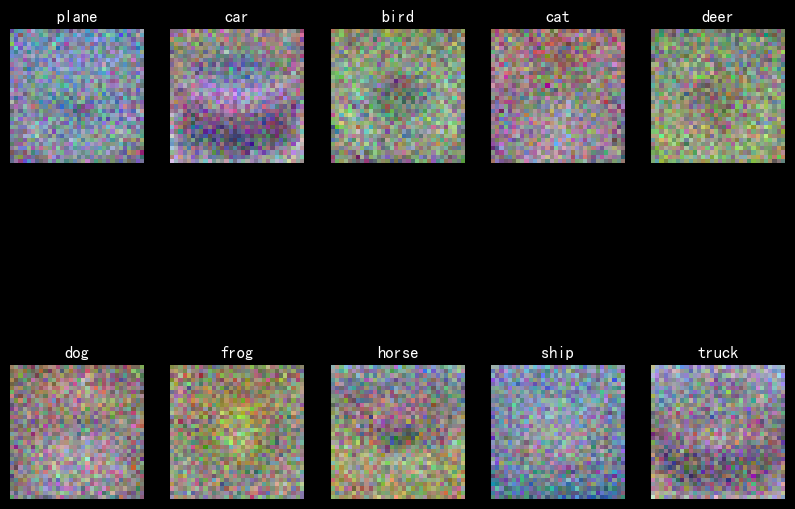

In [9]:
# 可视化每个分类的权重
#剥离偏置
w = best_softmax.W[:-1,:] 
#转换为图像格式
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # 将权重伸缩到 0 到 255 之间
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])